## Support Vector Machines


### Variable Target: rating

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib



from scipy.stats import loguniform
from scipy.stats import uniform
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold



In [3]:
df = pd.read_csv('../train_set/train_cleaned_outliers.csv')
test = pd.read_csv('../test_set/test_no_title.csv')
train = df.drop(columns=['originalTitle'])

Codifica:  
0 - Short  
1 - Movie  
2 - tvSeries  
3 - tvEpisode   
4 - Video  

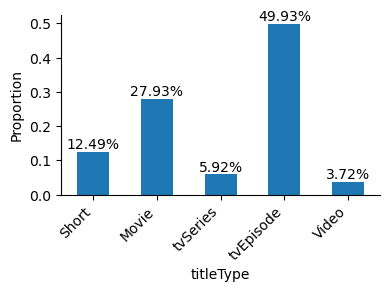

In [4]:
# ...existing code...

# Analisi distribuzione target
plt.figure(figsize=(4, 3))

# Ordina per titleType (indice) invece che per frequenza
titleType_counts = train['titleType'].value_counts().sort_index()
titleType_counts_norm = titleType_counts / titleType_counts.sum()

# Mapping delle etichette
titleType_labels = {
    0: 'Short',
    1: 'Movie', 
    2: 'tvSeries',
    3: 'tvEpisode',
    4: 'Video'
}

# Plot ordinato
ax = titleType_counts_norm.plot(kind='bar')

# add percentages on top of bars
for i, (titleType, v) in enumerate(titleType_counts_norm.items()):
    plt.text(i, v, f"{v:.2%}", ha='center', va='bottom')

# Sostituisci le etichette dell'asse x con i nomi descrittivi
ax.set_xticklabels([titleType_labels[titleType] for titleType in titleType_counts_norm.index], 
                   rotation=45, ha='right')

# remove up and right spines
sns.despine()
plt.ylabel('Proportion')
plt.tight_layout()  # Aggiustamento automatico del layout
plt.show()

In [5]:
X_train = train.drop(columns=['titleType'])
y_train = train['titleType']

X_test = test.drop(columns=['titleType', 'genreShort'])
y_test = test['titleType']

In [6]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
num_cols = [
    'averageRating',
    'numVotes', 
    'startYearDecade', 
    'runtimeHours',
    'totalCredits',
    'criticReviewsTotal',
    'userReviewsTotal',
    'castNumber',
    'companiesNumber',
    'writerCredits',
    'directorsCredits',
    'quotesTotal',
    'totalMedia',
    'totalRecognitions',
    ]

one_hot_cols = [
    "genreFamily", "genreDocumentary", "genreNews", "genreFilm-Noir", "genreWestern",
    "genreFantasy", "genreAdult", "genreAction", "genreMusic", "genreComedy",
    "genreSport", "genreHorror", "genreBiography", "genreTalk-Show",
    "genreDrama", "genreRomance", "genreWar", "genreMystery", "genreHistory",
    "genreSci-Fi", "genreAnimation", "genreAdventure", "genreReality-TV",
    "genreMusical", "genreThriller", "genreGame-Show", "genreCrime"
]

In [16]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)

# Range ampio centrato sul best_C con espansione logaritmica
param_dist_halving_linear = {
    'C': loguniform(1e-2,6),  # Range logaritmico ampio ±10x
    'class_weight': ['balanced', None],  # Testa entrambi
    'loss': ['hinge', 'squared_hinge'],  # Entrambe le loss functions
    'penalty': ['l2', 'l1'],  # L1 e L2 regularization
    'max_iter': [200000, 300000, 400000, 500000],  # Diverse iterazioni per convergenza
    'tol': [1e-3, 1e-4],  # Diverse tolleranze
}

linear_svc_explorer = LinearSVC(
    random_state=42)

# HalvingRandomSearchCV ottimizzato per LinearSVC
search_linear = HalvingRandomSearchCV(
    linear_svc_explorer,
    param_dist_halving_linear,
    factor=1.4,  # Elimina 2/3 dei candidati ad ogni iterazione
    resource='n_samples',  # Usa campioni crescenti
    max_resources='auto',  # Usa tutti i campioni nell'ultima iterazione
    min_resources=1500,  # Calcola automaticamente i campioni minimi
    n_candidates=1500,  # Numero iniziale alto per esplorazione ampia
    scoring='f1_macro', 
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search_linear.fit(X_train_scaled, y_train)

n_iterations: 13
n_required_iterations: 22
n_possible_iterations: 13
min_resources_: 1500
max_resources_: 93240
aggressive_elimination: False
factor: 1.4
----------
iter: 0
n_candidates: 1500
n_resources: 1500
Fitting 8 folds for each of 1500 candidates, totalling 12000 fits


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
2912 fits failed out of a total of 12000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2912 fits failed with the following error:
Traceback (most recent call last):
  File "/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/francesco/miniconda3/envs/datamin

----------
iter: 1
n_candidates: 1072
n_resources: 2100
Fitting 8 folds for each of 1072 candidates, totalling 8576 fits


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_search.py:1103: UserWarning: One or more of the test scores are non-finite: [       nan 0.55952695 0.68544274 ... 0.73163311 0.73188064 0.73024219]
  warnings.warn(
/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_search.py:1103: UserWarning: One or more of the train scores are non-finite: [       nan 0.60970318 0.74301556 ... 0.76977579 0.76875351 0.76868773]
  warnings.warn(


----------
iter: 2
n_candidates: 766
n_resources: 2939
Fitting 8 folds for each of 766 candidates, totalling 6128 fits


...

----------
iter: 11
n_candidates: 38
n_resources: 60743
Fitting 8 folds for each of 38 candidates, totalling 304 fits


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_search.py:1103: UserWarning: One or more of the test scores are non-finite: [       nan 0.55952695 0.68544274 ... 0.74492425 0.74492425 0.74495658]
  warnings.warn(
/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_search.py:1103: UserWarning: One or more of the train scores are non-finite: [       nan 0.60970318 0.74301556 ... 0.74648476 0.74649221 0.74649441]
  warnings.warn(


----------
iter: 12
n_candidates: 28
n_resources: 85040
Fitting 8 folds for each of 28 candidates, totalling 224 fits


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_search.py:1103: UserWarning: One or more of the test scores are non-finite: [       nan 0.55952695 0.68544274 ... 0.74410678 0.74399399 0.74399399]
  warnings.warn(
/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_search.py:1103: UserWarning: One or more of the train scores are non-finite: [       nan 0.60970318 0.74301556 ... 0.74579749 0.74577834 0.74576508]
  warnings.warn(


HalvingRandomSearchCV(cv=StratifiedKFold(n_splits=8, random_state=42, shuffle=True),
                      estimator=LinearSVC(random_state=42), factor=1.4,
                      min_resources=1500, n_candidates=1500, n_jobs=-1,
                      param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x73d914da7310>,
                                           'class_weight': ['balanced', None],
                                           'loss': ['hinge', 'squared_hinge'],
                                           'max_iter': [200000, 300000, 400000,
                                                        500000],
                                           'penalty': ['l2', 'l1'],
                                           'tol': [0.001, 0.0001]},
                      random_state=42, scoring='f1_macro', verbose=1)

In [18]:
best_model = search_linear.best_estimator_
joblib.dump(best_model, './models/svm_titleType.pkl')

['./models/svm_titleType.pkl']

In [21]:
# load best_model
best_model = joblib.load('./models/svm_titleType.pkl')


In [29]:
y_pred = best_model.predict(X_test_scaled)

# Calculate actual test F1 score
from sklearn.metrics import f1_score
test_f1_score = f1_score(y_test, y_pred, average='weighted')
train_f1_score = f1_score(y_train, best_model.predict(X_train_scaled), average='weighted')

print(f"Train F1 score: {train_f1_score:.6f}")
print(f"Test F1 score: {test_f1_score:.6f}")

# Evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix with correct labels
actual_ratings = sorted(y_test.unique())


Train F1 score: 0.844218
Test F1 score: 0.843146

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      4133
           1       0.84      0.87      0.85     10302
           2       0.78      0.75      0.76      2528
           3       0.87      0.90      0.89     18059
           4       0.62      0.30      0.40      1273

    accuracy                           0.85     36295
   macro avg       0.79      0.72      0.74     36295
weighted avg       0.84      0.85      0.84     36295



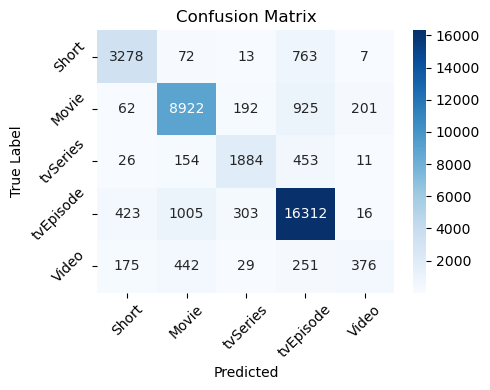

In [ ]:
# ...existing code...
label_map = {
    0: 'Short',
    1: 'Movie',
    2: 'tvSeries',
    3: 'tvEpisode',
    4: 'Video'
}

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))

# Crea le label per gli assi usando il mapping
class_labels = [label_map[i] for i in sorted(np.unique(y_test))]

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_labels,  # Label testuali per asse X
    yticklabels=class_labels   # Label testuali per asse Y
)

plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.tight_layout()  # Per migliorare il layout
plt.show()


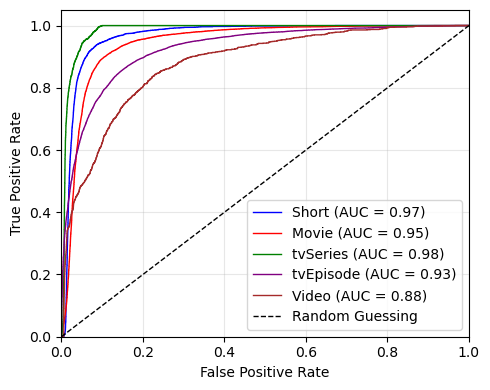


ROC AUC per classe:
Short: 0.967
Movie: 0.946
tvSeries: 0.985
tvEpisode: 0.926
Video: 0.878

ROC AUC media: 0.940


In [ ]:
# ...existing code...
# ROC curve per multiclass
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizza solo le etichette di test
y_test_bin = label_binarize(y_test, classes=sorted(np.unique(y_test)))
n_classes = y_test_bin.shape[1]

y_pred_proba = best_model.decision_function(X_test_scaled)

# Calcola le curve ROC e AUC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot delle curve ROC
plt.figure(figsize=(5, 4))
colors = ['blue', 'red', 'green', 'purple', 'brown', 'orange']

for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i], 
        color=colors[i % len(colors)],
        lw=1,
        label=f'{label_map[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calcola anche la ROC AUC media
print(f"\nROC AUC per classe:")
for i in range(n_classes):
    print(f"{label_map[i]}: {roc_auc[i]:.3f}")
print(f"\nROC AUC media: {np.mean(list(roc_auc.values())):.3f}")
# ...existing code...